# Creating final data for crop and fertilizer recommendation system

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fertilizer_data_path = '../Data-raw/FertilizerData.csv'
merge_fert = pd.read_csv(fertilizer_data_path)

In [3]:
merge_fert.head()

,Unnamed: 0,Crop,N,P,K,pH
0,0,rice,80,40,40,5.5
1,3,maize,80,40,20,5.5
2,5,chickpea,40,60,80,5.5
3,12,kidneybeans,20,60,20,5.5
4,13,pigeonpeas,20,60,20,5.5


In [4]:
del merge_fert['Unnamed: 0']

In [5]:
merge_fert.describe()

,N,P,K,pH
count,418.000000,418.000000,418.000000,418.000000
mean,50.454545,45.681818,48.181818,5.409091
std,35.523277,31.922068,50.570325,0.587768
min,20.000000,10.000000,10.000000,3.820000
25%,20.000000,20.000000,20.000000,5.320000
50%,30.000000,40.000000,30.000000,5.480000
75%,80.000000,60.000000,50.000000,5.620000
max,120.000000,125.000000,200.000000,6.680000


In [6]:
merge_fert['Crop'].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

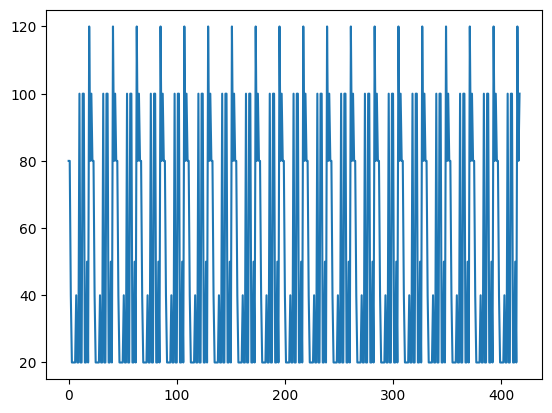

In [7]:
plt.plot(merge_fert["N"])

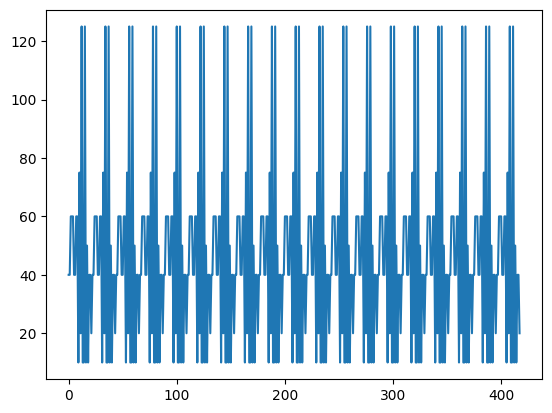

In [8]:
plt.plot(merge_fert["P"])

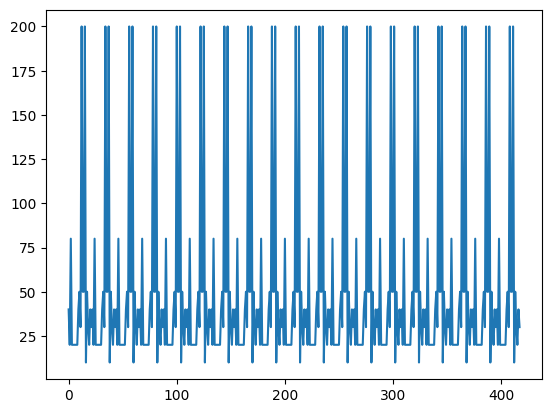

In [9]:
plt.plot(merge_fert["K"])

<Axes: >

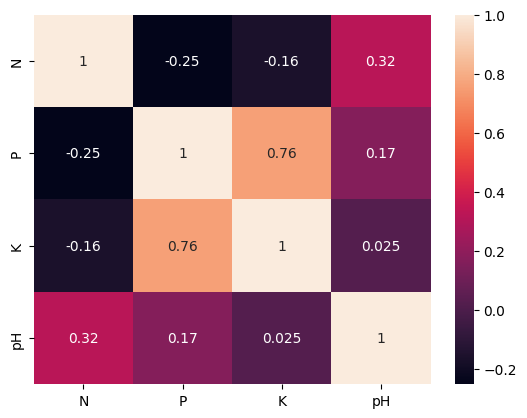

In [11]:
sns.heatmap(merge_fert.corr(numeric_only=True), annot=True)

In [12]:
merge_crop = pd.read_csv('../Data-raw/MergeFileCrop.csv')
reco_fert = merge_fert

In [14]:
#Add +/-3 for every NPK value
import random
import pandas as pd

rows = []

for i in range(merge_crop.shape[0]):
    crop = merge_crop['label'].iloc[i]

    N = reco_fert[reco_fert['Crop'] == crop]['N'].iloc[0] + random.randint(-20, 20)
    P = reco_fert[reco_fert['Crop'] == crop]['P'].iloc[0] + random.randint(-5, 20)
    K = reco_fert[reco_fert['Crop'] == crop]['K'].iloc[0] + random.randint(-5, 5)

    rows.append({"N": N, "P": P, "K": K})

temp = pd.DataFrame(rows)

In [15]:
temp

,N,P,K
0,83,48,44
1,90,37,40
2,64,47,37
3,98,54,43
4,95,55,43
...,...,...,...
2195,89,30,35
2196,96,39,29
2197,115,18,28
2198,82,39,35


In [16]:
merge_crop['N'] = temp['N']
merge_crop['P'] = temp['P']
merge_crop['K'] = temp['K']

In [17]:
merge_crop

,Unnamed: 0,temperature,humidity,ph,rainfall,label,N,P,K
0,0,20.879744,82.002744,6.502985,202.935536,rice,83,48,44
1,1,21.770462,80.319644,7.038096,226.655537,rice,90,37,40
2,2,23.004459,82.320763,7.840207,263.964248,rice,64,47,37
3,3,26.491096,80.158363,6.980401,242.864034,rice,98,54,43
4,4,20.130175,81.604873,7.628473,262.717340,rice,95,55,43
...,...,...,...,...,...,...,...,...,...
2195,2195,26.774637,66.413269,6.780064,177.774507,coffee,89,30,35
2196,2196,27.417112,56.636362,6.086922,127.924610,coffee,96,39,29
2197,2197,24.131797,67.225123,6.362608,173.322839,coffee,115,18,28
2198,2198,26.272418,52.127394,6.758793,127.175293,coffee,82,39,35


In [18]:
del merge_crop['Unnamed: 0']

In [19]:
merge_crop

,temperature,humidity,ph,rainfall,label,N,P,K
0,20.879744,82.002744,6.502985,202.935536,rice,83,48,44
1,21.770462,80.319644,7.038096,226.655537,rice,90,37,40
2,23.004459,82.320763,7.840207,263.964248,rice,64,47,37
3,26.491096,80.158363,6.980401,242.864034,rice,98,54,43
4,20.130175,81.604873,7.628473,262.717340,rice,95,55,43
...,...,...,...,...,...,...,...,...
2195,26.774637,66.413269,6.780064,177.774507,coffee,89,30,35
2196,27.417112,56.636362,6.086922,127.924610,coffee,96,39,29
2197,24.131797,67.225123,6.362608,173.322839,coffee,115,18,28
2198,26.272418,52.127394,6.758793,127.175293,coffee,82,39,35


In [20]:
merge_crop = merge_crop[[ 'N', 'P', 'K','temperature', 'humidity', 'ph', 'rainfall', 'label']]

In [21]:
merge_crop.to_csv("../Data-processed/crop_recommendation.csv",index=False)

In [22]:
# Checking if everything went fine
df = pd.read_csv('../Data-processed/crop_recommendation.csv')

In [23]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,83,48,44,20.879744,82.002744,6.502985,202.935536,rice
1,90,37,40,21.770462,80.319644,7.038096,226.655537,rice
2,64,47,37,23.004459,82.320763,7.840207,263.964248,rice
3,98,54,43,26.491096,80.158363,6.980401,242.864034,rice
4,95,55,43,20.130175,81.604873,7.628473,262.717340,rice


In [24]:
df.shape

(2200, 8)